In [1]:
###Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


In [2]:
#### Load the Datasets


users_df = pd.read_csv(r"C:\Users\shara\OneDrive\Desktop\JAIN\Dataset_DSAI\Dataset\cellphone_users.csv", encoding='latin1')
phones_df = pd.read_csv(r"C:\Users\shara\OneDrive\Desktop\JAIN\Dataset_DSAI\Dataset\cellphones_data.csv", encoding='latin1')
ratings_df = pd.read_csv(r"C:\Users\shara\OneDrive\Desktop\JAIN\Dataset_DSAI\Dataset\cellphones_ratings.csv", encoding='latin1')

In [5]:
###Step 1: Dataset Merging using common columns
## user_id
## cellphone_id

df = ratings_df.merge(users_df, on='user_id', how='left') \
            .merge(phones_df, on='cellphone_id', how='left')


In [12]:
df.head()


,user_id,cellphone_id,rating,user_name,Region(City),Salary_in_INR,age,gender,occupation,brand,...,internal memory,RAM,performance,main camera,selfie camera,battery size,screen size,weight,price(INR),release date
0,0,30,1,Ram,Delhi,570500.0,38.0,Female,Data analyst,Motorola,...,32,3,1.42,13,5,5000,6.5,204,13888.65,14/01/2021
1,0,5,3,Ram,Delhi,570500.0,38.0,Female,Data analyst,Apple,...,64,3,4.22,12,7,2942,6.1,194,20614.60,26/10/2018
2,0,10,9,Ram,Delhi,570500.0,38.0,Female,Data analyst,Samsung,...,128,8,8.81,50,10,3700,6.1,167,46120.80,25/02/2022
3,0,9,3,Ram,Delhi,570500.0,38.0,Female,Data analyst,Samsung,...,128,6,3.79,64,32,5000,6.5,189,27253.20,24/03/2022
4,0,23,2,Ram,Delhi,570500.0,38.0,Female,Data analyst,Vivo,...,256,8,9.81,50,32,4700,6.7,215,76169.20,29/04/2022


In [13]:
df.all()

user_id             False
cellphone_id        False
rating               True
user_name            True
Region(City)         True
Salary_in_INR        True
age                  True
gender               True
occupation           True
brand                True
model                True
operating system     True
internal memory      True
RAM                  True
performance          True
main camera          True
selfie camera        True
battery size         True
screen size          True
weight               True
price(INR)           True
release date         True
dtype: bool

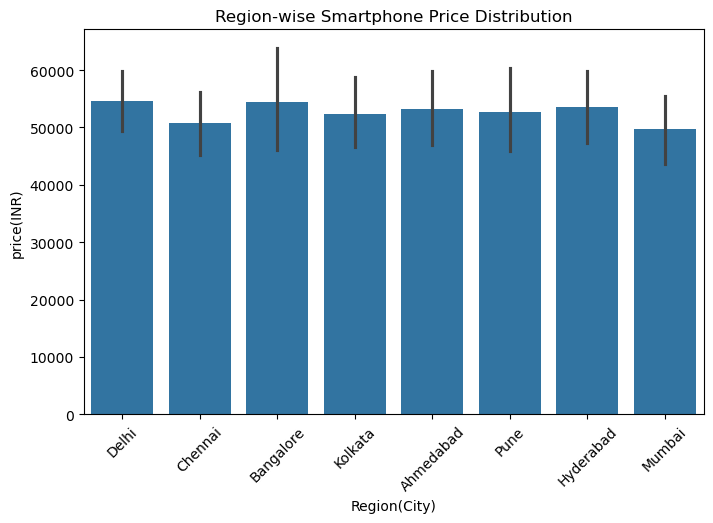

In [19]:
####Step 2: Marketing Budget Setup
##Region-wise price analysis


plt.figure(figsize=(8,5))
sns.barplot(x='Region(City)', y='price(INR)', data=df)
plt.xticks(rotation=45)
plt.title("Region-wise Smartphone Price Distribution")
plt.show()

In [20]:
#Create Marketing_Budget column (30% of price)

df['Marketing_Budget'] = df['price(INR)'] * 0.30


In [21]:
######step 3. Model Building 

#Remove features that are irrelevant to model performance based on domain understanding and feature correlation analysis. 
df_model = df.drop(columns=['user_id','phone_id','username','email'], errors='ignore')
df_model = pd.get_dummies(df_model, drop_first=True)


In [22]:
#Spliting the data into training and testing sets, using Marketing_Budget as the dependent variable. 

X = df_model.drop('Marketing_Budget', axis=1)
y = df_model['Marketing_Budget']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [23]:
####Step 4. Model Evaluation 

# Initialize the Linear Regression model and train it using the training dataset
# (X_train contains input features and y_train contains the target variable)
model = LinearRegression()
model.fit(X_train, y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
# Predict the target values using the trained model on the test dataset
y_pred = model.predict(X_test)

# Evaluate the model performance using R² score, Mean Squared Error (MSE),
# and Root Mean Squared Error (RMSE)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Display the evaluation metrics
print("R2 Score:", r2)
print("MSE:", mse)
print("RMSE:", rmse)


R2 Score: 1.0
MSE: 1.4150292567874139e-21
RMSE: 3.761687462811622e-11


In [25]:
#########step 5. Prediction 

# Display a comparison of actual and predicted values for the test dataset

pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}).head()




,Actual,Predicted
213,31419.795,31419.795
331,11215.740,11215.740
501,31419.795,31419.795
309,6184.380,6184.380
88,11766.045,11766.045
